In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
from google.colab import files
f = files.upload()

Saving M8_country_profile_variables.csv to M8_country_profile_variables.csv


### 1.1 Compute the difference between the life expectancy of males and females for all the countries. Display the top-10 countries where is the difference of life expectancy between males and females is the highest. Display the difference of life expectancy between males and females in the ‘United State of America’.

In [3]:
# Step# 1
#

country = pd.read_csv('M8_country_profile_variables.csv')
print(country.head(5))
print(country.tail(5))
print(country.shape)

print(type(country))

   Unnamed: 0         Country  Surface area (km2)  Population 1,000  (2017)  \
0           1     Afghanistan              652864                     35530   
1           2         Albania               28748                      2930   
2           3         Algeria             2381741                     41318   
3           4  American Samoa                 199                        56   
4           5          Angola             1246700                     29784   

   GDP (M US$)  Life Exp Female  Life Exp Male  
0        20270             63.5           61.0  
1        11541             79.9           75.6  
2       164779             76.5           74.1  
3          -99             77.8           71.1  
4       117955             63.0           57.4  
     Unnamed: 0                    Country  Surface area (km2)  \
206         207  Wallis and Futuna Islands                 142   
207         208             Western Sahara              266000   
208         209                  

In [4]:
country["Difference"] = country["Life Exp Female"] - country["Life Exp Male"]

top10_difference = country.sort_values("Difference", ascending=False).head(10)
top10_difference

,Unnamed: 0,Country,Surface area (km2),"Population 1,000 (2017)",GDP (M US$),Life Exp Female,Life Exp Male,Difference
182,183,Syrian Arab Republic,185180,18270,28393,76.3,64.4,11.9
154,155,Russian Federation,17098246,143990,1326016,75.9,64.7,11.2
16,17,Belarus,207600,9468,54609,77.7,66.5,11.2
107,108,Lithuania,65286,2890,41402,79.3,68.5,10.8
102,103,Latvia,64573,1950,27004,78.7,68.8,9.9
195,196,Ukraine,603500,44223,90615,76.0,66.1,9.9
141,142,Palau,459,22,258,77.8,68.1,9.7
96,97,Kazakhstan,2724902,18204,181754,73.9,64.3,9.6
205,206,Viet Nam,330967,95541,193241,80.3,70.7,9.6
60,61,Estonia,45227,1310,22460,81.2,71.8,9.4


In [5]:
country.loc[country['Country'] ==  'United States of America']

,Unnamed: 0,Country,Surface area (km2),"Population 1,000 (2017)",GDP (M US$),Life Exp Female,Life Exp Male,Difference
199,200,United States of America,9833517,324460,18036648,81.2,76.5,4.7


###1.2 Compute the “average life expectancy” of males and females for all the countries. We will use this variable in the next 2 problems (1.3 + 1.4).

In [6]:
## for question #2, the  “average life expectancy”  is the new columns for average of male and female only

In [7]:
country['averageLifeExp'] = (country['Life Exp Female'] + country['Life Exp Male'])/2
print(country.head(5))

   Unnamed: 0         Country  Surface area (km2)  Population 1,000  (2017)  \
0           1     Afghanistan              652864                     35530   
1           2         Albania               28748                      2930   
2           3         Algeria             2381741                     41318   
3           4  American Samoa                 199                        56   
4           5          Angola             1246700                     29784   

   GDP (M US$)  Life Exp Female  Life Exp Male  Difference  averageLifeExp  
0        20270             63.5           61.0         2.5           62.25  
1        11541             79.9           75.6         4.3           77.75  
2       164779             76.5           74.1         2.4           75.30  
3          -99             77.8           71.1         6.7           74.45  
4       117955             63.0           57.4         5.6           60.20  


In [8]:
sortedTable = country.sort_values(['Difference'],ascending=False)
print(sortedTable.head(5))
print(sortedTable.shape)
sortedTable.loc[sortedTable['Country'] ==  'United States of America']

     Unnamed: 0               Country  Surface area (km2)  \
182         183  Syrian Arab Republic              185180   
154         155    Russian Federation            17098246   
16           17               Belarus              207600   
107         108             Lithuania               65286   
102         103                Latvia               64573   

     Population 1,000  (2017)  GDP (M US$)  Life Exp Female  Life Exp Male  \
182                     18270        28393             76.3           64.4   
154                    143990      1326016             75.9           64.7   
16                       9468        54609             77.7           66.5   
107                      2890        41402             79.3           68.5   
102                      1950        27004             78.7           68.8   

     Difference  averageLifeExp  
182        11.9           70.35  
154        11.2           70.30  
16         11.2           72.10  
107        10.8           73

,Unnamed: 0,Country,Surface area (km2),"Population 1,000 (2017)",GDP (M US$),Life Exp Female,Life Exp Male,Difference,averageLifeExp
199,200,United States of America,9833517,324460,18036648,81.2,76.5,4.7,78.85


### 1.3 Create 2 scatter bubble charts between GDP and “average life expectancy” for all the countries in the dataset.


In [9]:
countryName = country['Country']
GDP = country['GDP (M US$)']
averageLifeExp = sortedTable['averageLifeExp']

marker_size_P = country['Population 1,000  (2017)']/1000 # Proportional to the Population
marker_size_SA = country['Surface area (km2)']/10000 # Proportional to the Surface Area


### • In the first chart the size of the bubble should be proportional to the population of the country.
### • In the second chart the size of the bubble should be proportional to the surface area of the country.

In [10]:
np.log(country['GDP (M US$)'])

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,GDP (M US$)
0,9.916897
1,9.353661
2,12.012360
3,NaN
4,11.678058
...,...
206,NaN
207,NaN
208,10.298498
209,9.964347


/usr/local/lib/python3.13/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


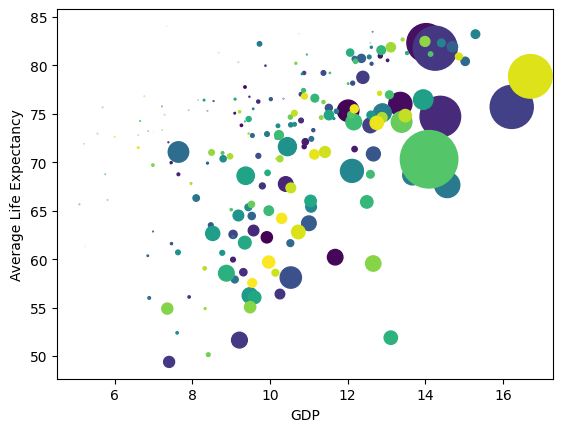

In [11]:
fig, ax = plt.subplots()

ax.scatter(np.log(country['GDP (M US$)']), country['averageLifeExp'],
           s=country['Surface area (km2)']/10000,
           c = range(len(country['Country'])))
ax.set_xlabel("GDP")
ax.set_ylabel("Average Life Expectancy")
plt.show()

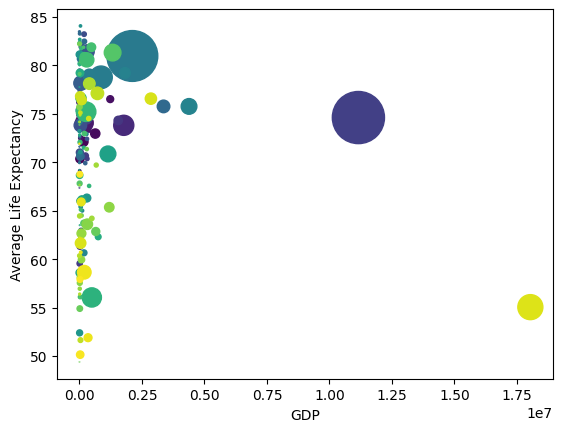

In [12]:
fig, ax = plt.subplots()

ax.scatter(GDP, averageLifeExp, s=marker_size_P, c = range(len(countryName)))
ax.set_xlabel("GDP")
ax.set_ylabel("Average Life Expectancy")
plt.show()

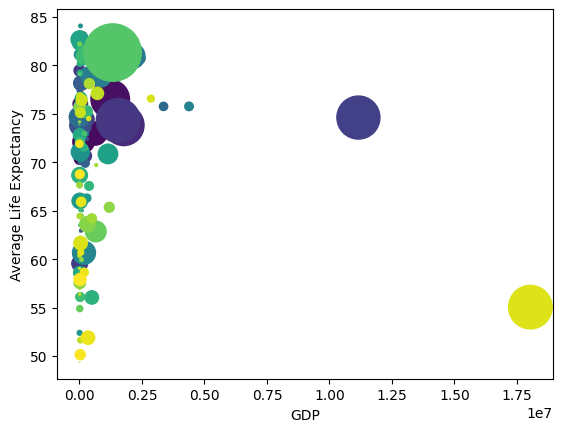

In [13]:
fig, ax = plt.subplots()

ax.scatter(GDP, averageLifeExp, s=marker_size_SA, c = range(len(countryName)))
ax.set_xlabel("GDP")
ax.set_ylabel("Average Life Expectancy")
plt.show()

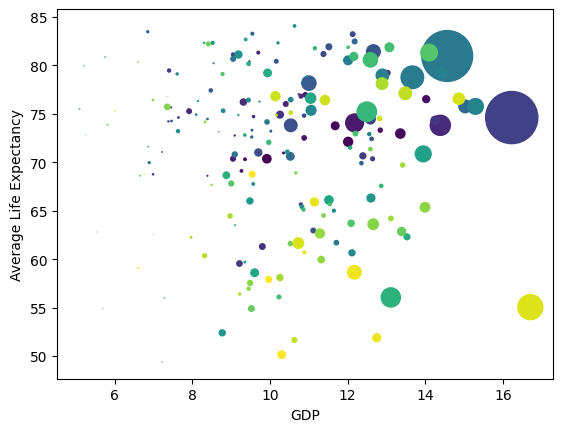

In [14]:
fig, ax = plt.subplots()

ax.scatter(np.log(GDP), averageLifeExp, s=marker_size_P, c = range(len(countryName)))
ax.set_xlabel("GDP")
ax.set_ylabel("Average Life Expectancy")
plt.show()

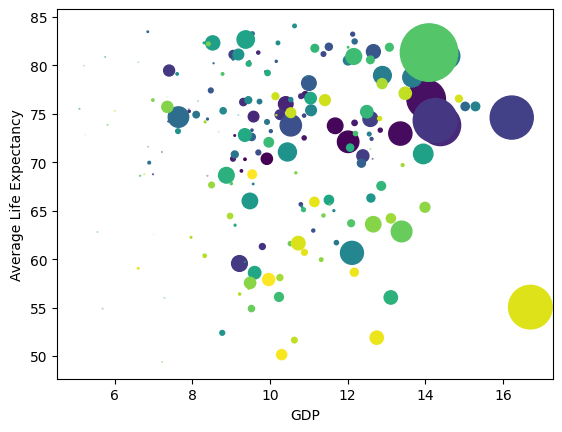

In [15]:
fig, ax = plt.subplots()

ax.scatter(np.log(GDP), averageLifeExp, s=marker_size_SA, c = range(len(countryName)))
ax.set_xlabel("GDP")
ax.set_ylabel("Average Life Expectancy")
plt.show()